In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
import nltk

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to C:\Users\LAPTOPS
[nltk_data]     HUB\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\LAPTOPS
[nltk_data]     HUB\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [2]:
# Loading the dataset
import os
csv_path = 'Reviews.csv' if os.path.exists('Reviews.csv') else 'notebooks/Reviews.csv'
df = pd.read_csv(csv_path)

# RENAMING AND SELECTING COLUMNS
df.rename(columns={'Summary': 'Sentiment_Summary'}, inplace=True)

# Keep only necessary columns
df = df[['Score', 'Sentiment_Summary', 'Text']]

print("Initial Data Shape Prosessed:", df.shape)
df.head()

Initial Data Shape Prosessed: (568454, 3)


,Score,Sentiment_Summary,Text
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,4,"""Delight"" says it all",This is a confection that has been around a fe...
3,2,Cough Medicine,If you are looking for the secret ingredient i...
4,5,Great taffy,Great taffy at a great price. There was a wid...


In [3]:
# Mapping Score to Sentiment labels
def get_sentiment(score):
    if score > 3:
        return 'Positive'
    elif score < 3:
        return 'Negative'
    else:
        return 'Neutral'

df['Sentiment'] = df['Score'].apply(get_sentiment)
df.head()

,Score,Sentiment_Summary,Text,Sentiment
0,5,Good Quality Dog Food,I have bought several of the Vitality canned d...,Positive
1,1,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...,Negative
2,4,"""Delight"" says it all",This is a confection that has been around a fe...,Positive
3,2,Cough Medicine,If you are looking for the secret ingredient i...,Negative
4,5,Great taffy,Great taffy at a great price. There was a wid...,Positive


In [4]:
# Text Preprocessing Function
def clean_text(text):
    if not isinstance(text, str):
        return ""
    
    # Lowercasing
    text = text.lower()
    
    # Removing HTML tags
    text = re.sub('<.*?>', '', text)
    
    # Removing punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Removing numbers
    text = re.sub(r'\d+', '', text)
    
    # Removing stopwords
    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [w for w in words if w not in stop_words]
    
    return " ".join(words)

print("Preprocessing function defined.")

Preprocessing function defined.


In [5]:
# Apply preprocessing to the Text column
print("Applying preprocessing... (This may take a moment for large datasets)")
# Processing first 50k for testing speed, adjust as needed
df = df.head(50000)
df['Cleaned_Text'] = df['Text'].apply(clean_text)

print("Preprocessing Complete.")
df[['Score', 'Sentiment', 'Cleaned_Text']].head()

Applying preprocessing... (This may take a moment for large datasets)
Preprocessing Complete.


,Score,Sentiment,Cleaned_Text
0,5,Positive,bought several vitality canned dog food produc...
1,1,Negative,product arrived labeled jumbo salted peanutsth...
2,4,Positive,confection around centuries light pillowy citr...
3,2,Negative,looking secret ingredient robitussin believe f...
4,5,Positive,great taffy great price wide assortment yummy ...


In [6]:
# Feature Extraction using CountVectorizer
cv = CountVectorizer(max_features=50)
X = cv.fit_transform(df['Cleaned_Text']).toarray()
y = df['Sentiment']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 50)
y shape: (50000,)


In [7]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Set Size:", X_train.shape[0])
print("Testing Set Size:", X_test.shape[0])

Training Set Size: 40000
Testing Set Size: 10000


C:\Users\LAPTOPS HUB\AppData\Local\Temp\ipykernel_3688\3424548023.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentiment', data=df, palette='viridis')


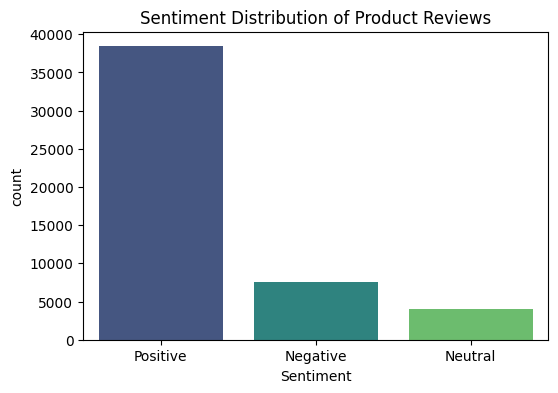

In [8]:
# Visualization of Sentiment Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Sentiment', data=df, palette='viridis')
plt.title('Sentiment Distribution of Product Reviews')
plt.show()

In [ ]:
import dagshub
import mlflow
import mlflow.sklearn
mlflow.set_tracking_uri("")
dagshub.init(repo_owner='',repo_name='Product-review-intelligence-system',mlflow=True)

mlflow.set_experiment("Logistic-Regression-baseline")

c:\Users\LAPTOPS HUB\Desktop\Product-review-intelligence-system\myvenv\lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
c:\Users\LAPTOPS HUB\Desktop\Product-review-intelligence-system\myvenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Accessing as mudassarhussain6533

Initialized MLflow to track repo "mudassarhussain6533/Product-review-intelligence-system"

Repository mudassarhussain6533/Product-review-intelligence-system initialized!

<Experiment: artifact_location='mlflow-artifacts:/56de838452da49abbddb59b0cd12b451', creation_time=1772723728564, experiment_id='0', last_update_time=1772723728564, lifecycle_stage='active', name='Logistic-Regression-baseline', tags={'mlflow.experimentKind': 'custom_model_development'}, workspace='default'>

In [10]:
import mlflow
import logging
import os
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score
from sklearn.linear_model import LogisticRegression

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logging.info("Starting the experiment")

with mlflow.start_run():
     start_time = time.time()
     try:
        logging.info("Logging preprocessing parameters")
        mlflow.log_param("vectorizer", "bow")
        mlflow.log_param("num_features", 50)
        mlflow.log_param("test_size", 0.2)
        mlflow.log_param("random_state", 42)

        logging.info("initializing  LogisticRegression model")
        model = LogisticRegression(max_iter=1000)

        logging.info("Training the model")
        model.fit(X_train, y_train)
        logging.info("Model training completed")

        logging.info("Logging model parameters")
        mlflow.log_param("model", "LogisticRegression")


        logging.info("Predicting on test data")
        y_pred = model.predict(X_test)

        logging.info("Calculating evaluation metrics")
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        logging.info("Logging evaluation metrics")
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1", f1)
        
        
        
        logging.info('Saving and logging model')
        mlflow.sklearn.log_model(model, "model")


        end_time = time.time()
        logging.info(f"Experiment completed in {end_time - start_time:.2f} seconds")



        logging.info(f'accuracy: {accuracy:.4f}')
        logging.info(f'precision: {precision:.4f}')
        logging.info(f'recall: {recall:.4f}')
        logging.info(f'f1: {f1:.4f}')

     except Exception as e:
        logging.error(f"Experiment failed: {str(e)}")
        raise e
        
        
        
        
        
        


2026-03-07 22:09:00,604 - INFO - Starting the experiment


2026-03-07 22:09:02,785 - INFO - Logging preprocessing parameters
2026-03-07 22:09:04,103 - INFO - initializing  LogisticRegression model
2026-03-07 22:09:04,105 - INFO - Training the model
2026-03-07 22:09:05,208 - INFO - Model training completed
2026-03-07 22:09:05,217 - INFO - Logging model parameters
2026-03-07 22:09:05,523 - INFO - Predicting on test data
2026-03-07 22:09:05,547 - INFO - Calculating evaluation metrics
2026-03-07 22:09:05,588 - ERROR - Experiment failed: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].


🏃 View run abundant-calf-166 at: https://dagshub.com/mudassarhussain6533/Product-review-intelligence-system.mlflow/#/experiments/0/runs/44eb84bab1e949e6a08e6b62d608dff4
🧪 View experiment at: https://dagshub.com/mudassarhussain6533/Product-review-intelligence-system.mlflow/#/experiments/0


ValueError: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].